# Análisis Exploratorio de Datos: Enfermedades Cardiovasculares

## 1. Introducción

Este notebook presenta el Análisis Exploratorio de Datos (EDA) del conjunto de datos "Cardiovascular Disease Dataset", que contiene información clínica de 70,000 pacientes. El objetivo es identificar patrones y relaciones entre variables que permitan comprender los factores asociados con enfermedades cardiovasculares.

### 1.1 Descripción del Dataset

El dataset incluye las siguientes variables:

**Variables demográficas:**
- `age`: Edad del paciente (en días)
- `gender`: Sexo (1: mujer, 2: hombre)
- `height`: Altura (cm)
- `weight`: Peso (kg)

**Variables clínicas:**
- `ap_hi`: Presión arterial sistólica (mmHg)
- `ap_lo`: Presión arterial diastólica (mmHg)
- `cholesterol`: Nivel de colesterol (1: normal, 2: por encima de lo normal, 3: muy por encima de lo normal)
- `gluc`: Nivel de glucosa (1: normal, 2: por encima de lo normal, 3: muy por encima de lo normal)

**Variables de estilo de vida:**
- `smoke`: Fumador (0: no, 1: sí)
- `alco`: Consumo de alcohol (0: no, 1: sí)
- `active`: Actividad física (0: no, 1: sí)

**Variable objetivo:**
- `cardio`: Presencia de enfermedad cardiovascular (0: no, 1: sí)

## 2. Importación de Bibliotecas y Configuración

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Configuración
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10

# Ruta del dataset
RAW_DATA_PATH = '../data/raw/cardio_train.csv'

## 3. Carga y Exploración Inicial de Datos

In [2]:
# Cargar dataset
df = pd.read_csv(RAW_DATA_PATH, sep=';')

print(f"Dimensiones del dataset: {df.shape[0]:,} registros × {df.shape[1]} variables")
print("\nPrimeras observaciones:")
df.head(10)

Dimensiones del dataset: 70,000 registros × 13 variables

Primeras observaciones:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [3]:
# Información general del dataset
print("Información del dataset:")
df.info()

print(f"\n{'='*60}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Registros duplicados: {df.duplicated().sum():,}")

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Valores nulos: 0
Registros duplicados: 0


## 4. Análisis Descriptivo

### 4.1 Estadísticas Descriptivas

In [4]:
# Crear variable edad en años para mejor interpretación
df['age_years'] = (df['age'] / 365.25).round(1)

# Estadísticas descriptivas
columnas_interes = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 
                     'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

descripcion = df[columnas_interes].describe().round(2)
descripcion

,age_years,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.00,70000.0,70000.0
mean,53.30,164.36,74.21,128.82,96.63,1.37,1.23,0.09,0.05,0.8,0.5
std,6.76,8.21,14.40,154.01,188.47,0.68,0.57,0.28,0.23,0.4,0.5
min,29.60,55.00,10.00,-150.00,-70.00,1.00,1.00,0.00,0.00,0.0,0.0
25%,48.40,159.00,65.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
50%,53.90,165.00,72.00,120.00,80.00,1.00,1.00,0.00,0.00,1.0,0.0
75%,58.40,170.00,82.00,140.00,90.00,2.00,1.00,0.00,0.00,1.0,1.0
max,64.90,250.00,200.00,16020.00,11000.00,3.00,3.00,1.00,1.00,1.0,1.0


**Observaciones:**

- La edad promedio de los pacientes es de 53.3 años, con un rango de 29 a 65 años
- El peso promedio es de 74.21 kg con una altura promedio de 164.36 cm
- La presión arterial sistólica promedio es 128.82 mmHg y la diastólica 96.63 mmHg
- El 50% de los pacientes presenta enfermedad cardiovascular

### 4.2 Distribución de la Variable Objetivo

Distribución de Enfermedad Cardiovascular:

Sin enfermedad: 35,021 pacientes (50.03%)
Con enfermedad: 34,979 pacientes (49.97%)


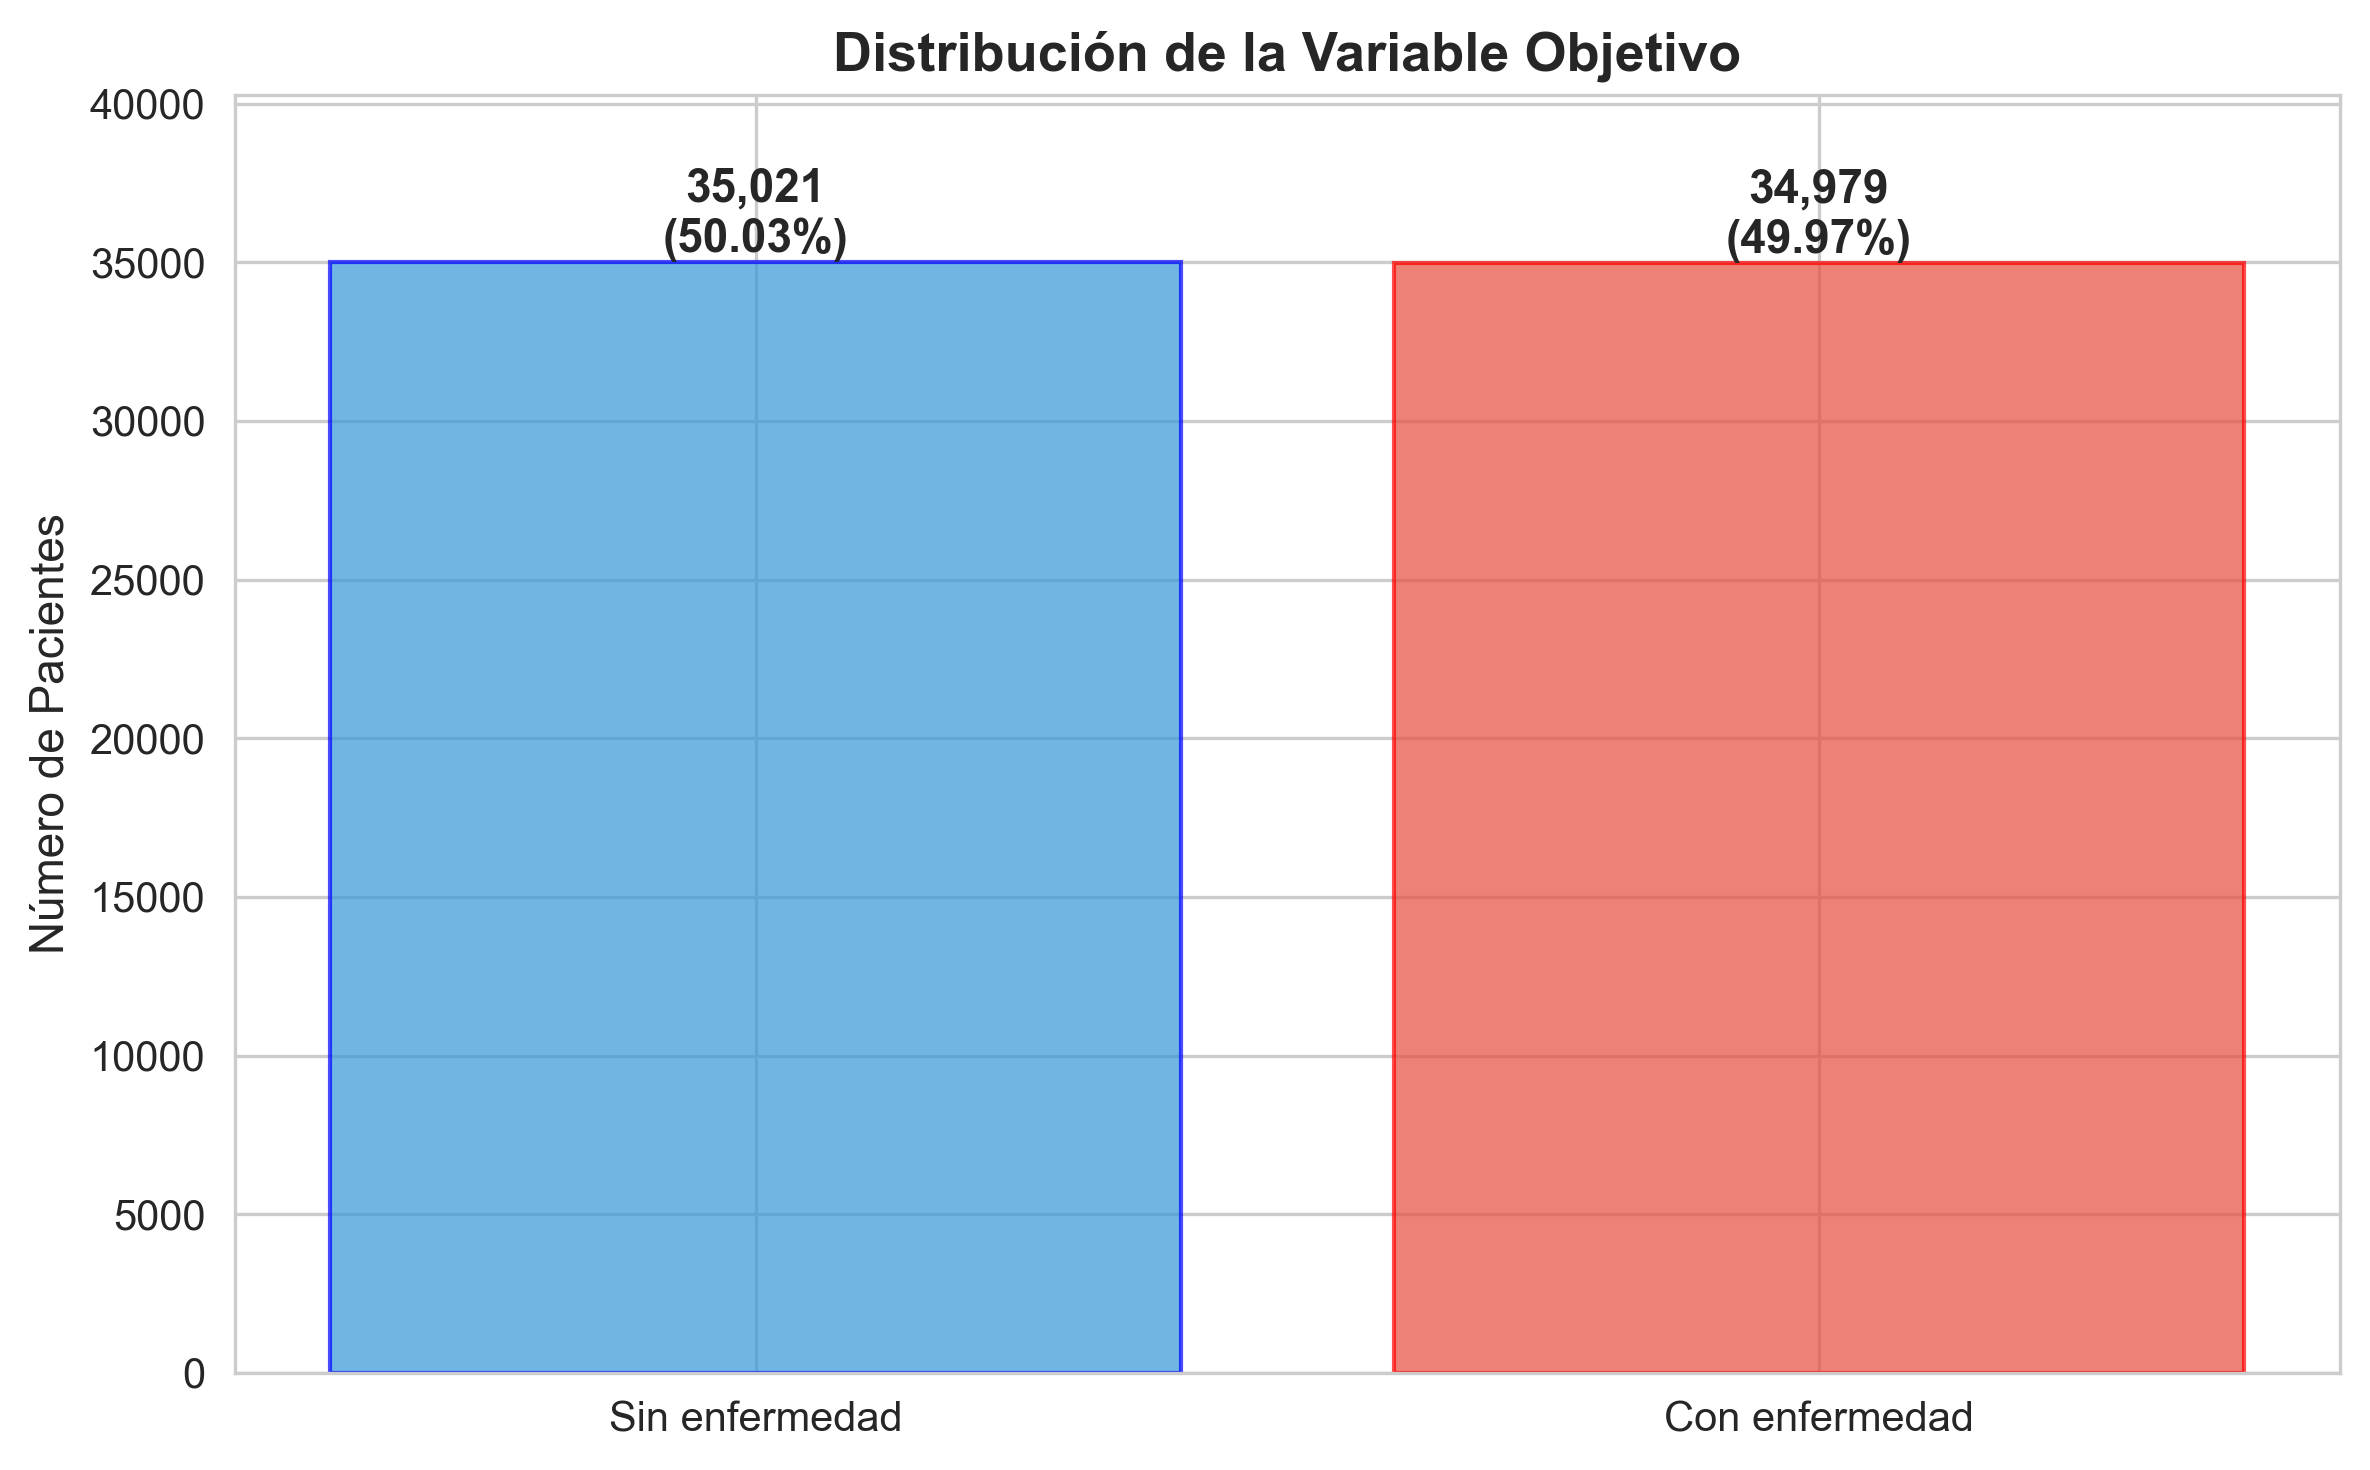

In [5]:
# Distribución de la variable objetivo
distribucion = df['cardio'].value_counts()
porcentaje = df['cardio'].value_counts(normalize=True) * 100

print("Distribución de Enfermedad Cardiovascular:\n")
for val, count, pct in zip(distribucion.index, distribucion.values, porcentaje.values):
    estado = "Sin enfermedad" if val == 0 else "Con enfermedad"
    print(f"{estado}: {count:,} pacientes ({pct:.2f}%)")

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Sin enfermedad', 'Con enfermedad'], distribucion.values, 
               color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor=['blue', 'red'])

# Agregar valores en las barras
for bar, val, pct in zip(bars, distribucion.values, porcentaje.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:,}\n({pct:.2f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Número de Pacientes', fontsize=11)
ax.set_title('Distribución de la Variable Objetivo', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(distribucion.values) * 1.15)
plt.tight_layout()
plt.show()

**Interpretación:** El dataset está balanceado, con una proporción casi equitativa entre pacientes con y sin enfermedad cardiovascular. Esto es favorable para el desarrollo de modelos predictivos, ya que no requiere técnicas de balanceo de clases.

## 5. Análisis de Variables Numéricas

### 5.1 Distribuciones y Detección de Anomalías

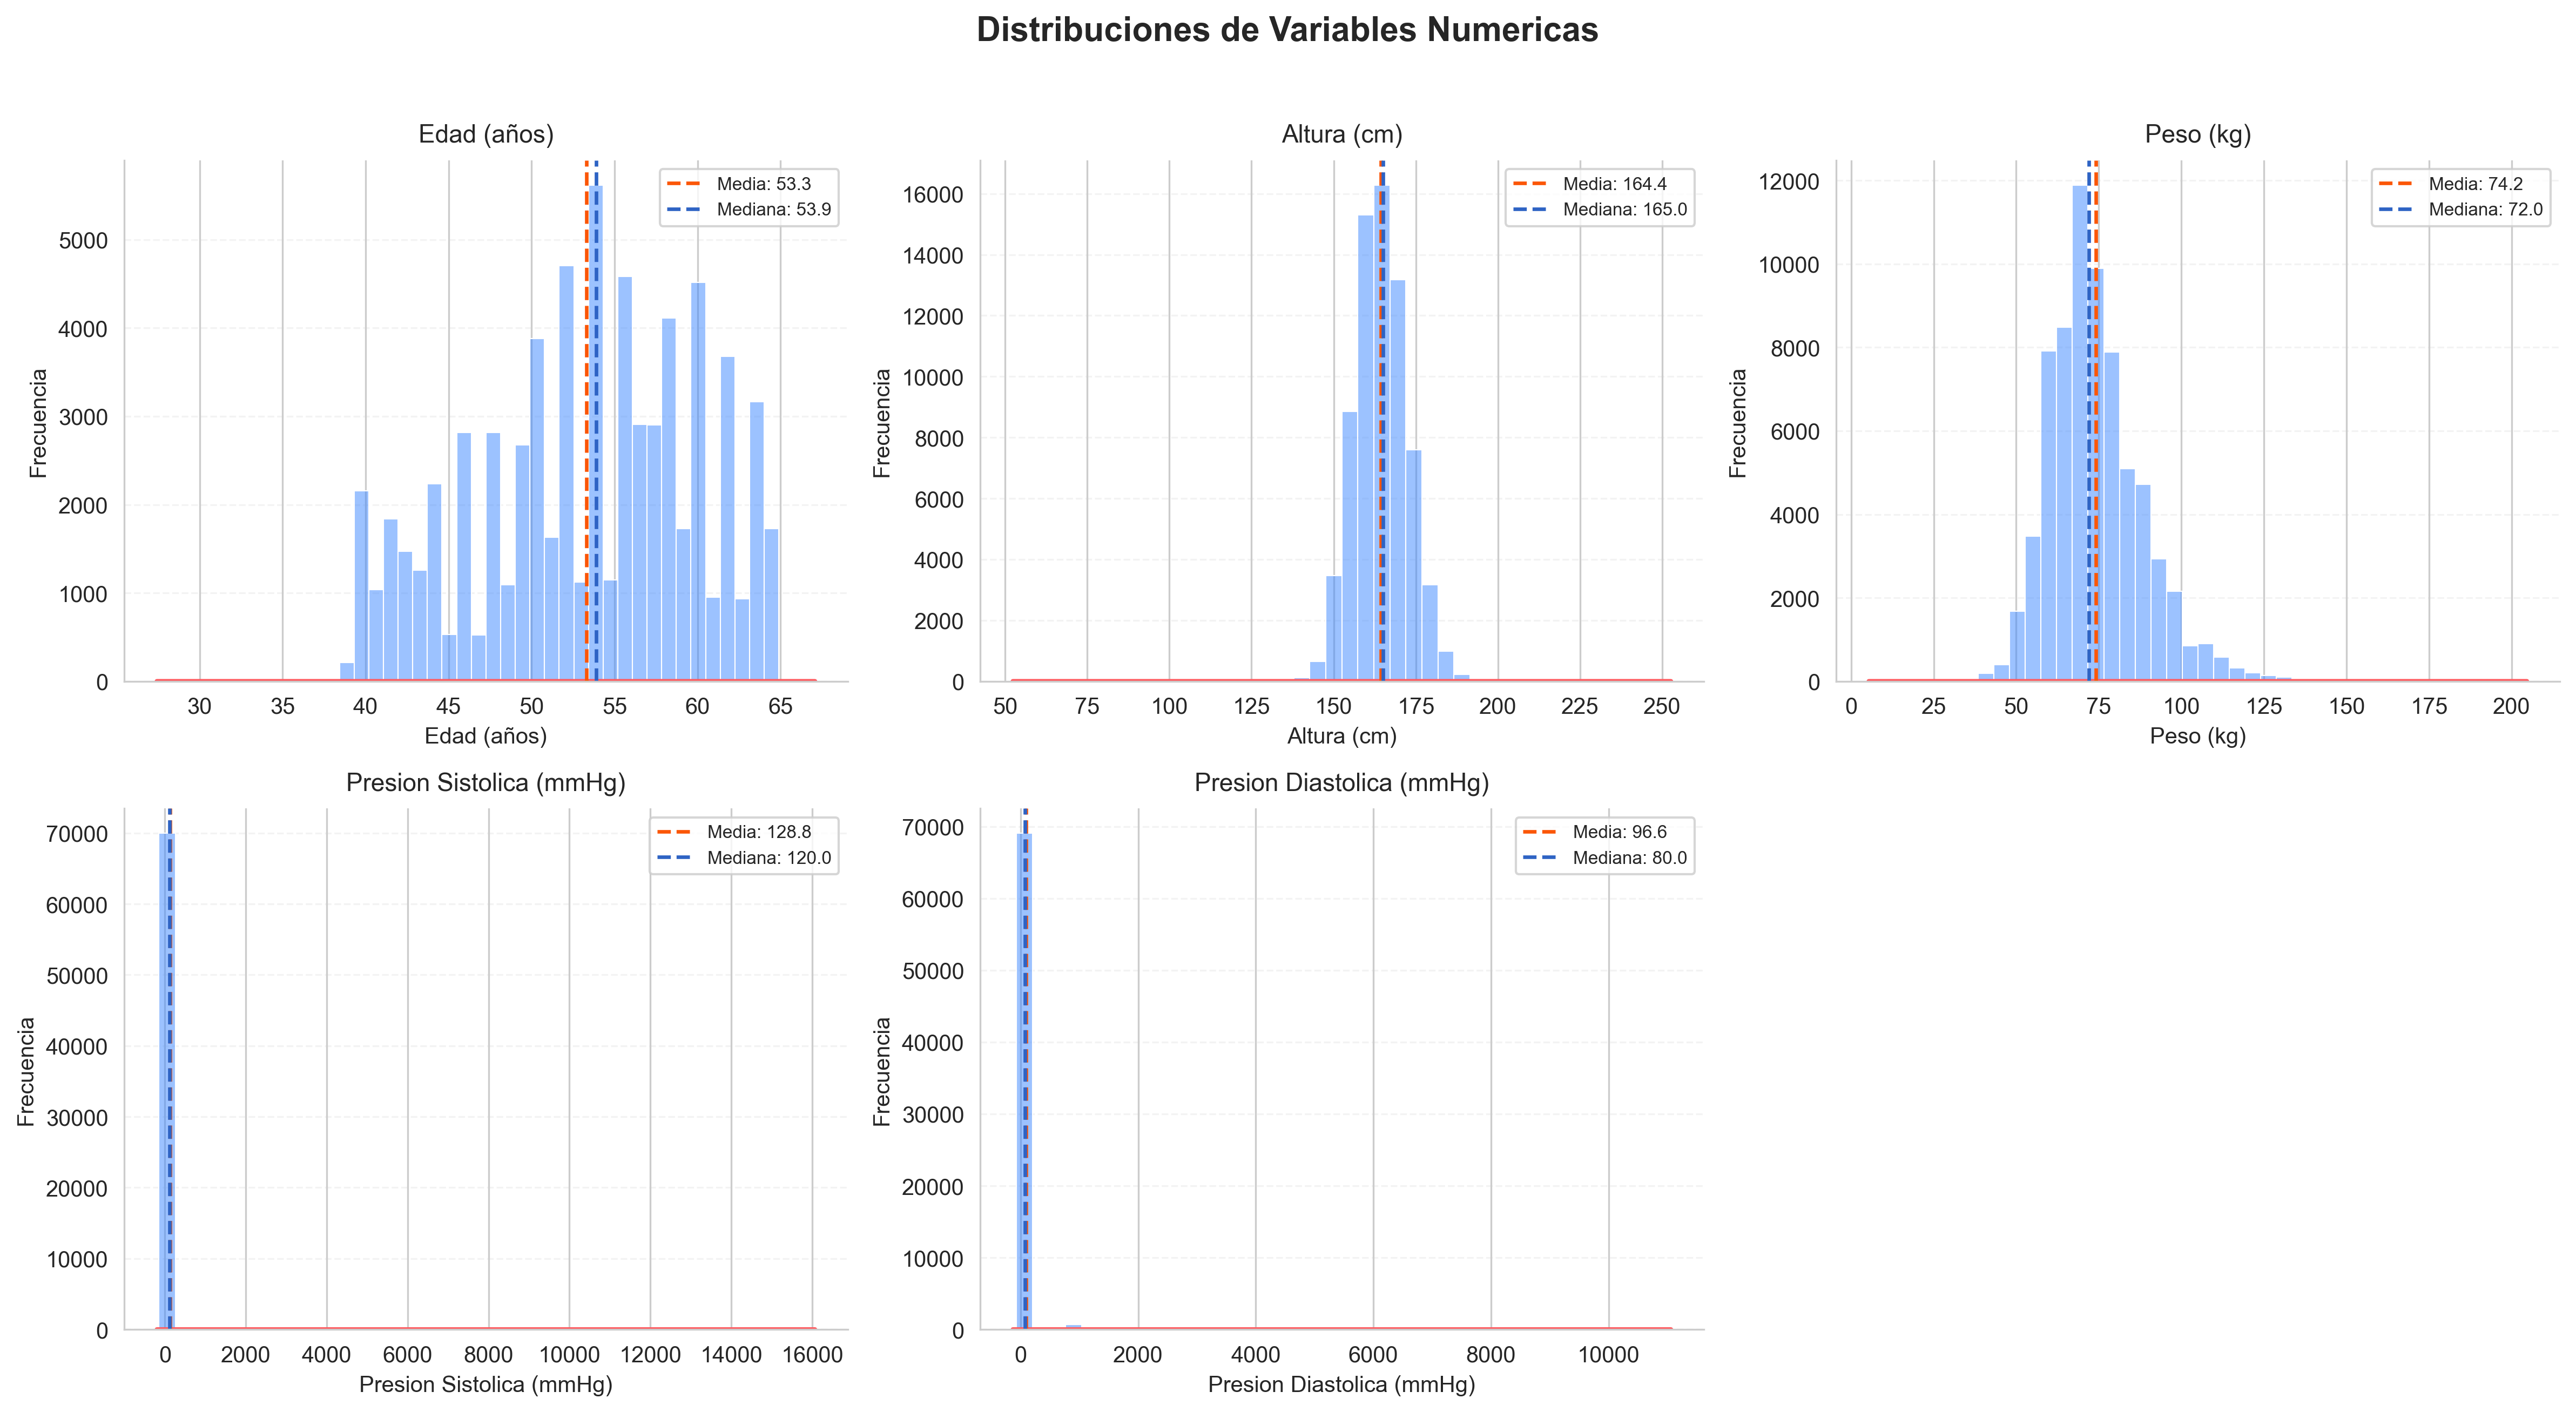

In [6]:
# Variables numericas de interes
variables_num = {
    'age_years': 'Edad (años)',
    'height': 'Altura (cm)',
    'weight': 'Peso (kg)',
    'ap_hi': 'Presion Sistolica (mmHg)',
    'ap_lo': 'Presion Diastolica (mmHg)'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
axes = axes.flatten()

for idx, (col, nombre) in enumerate(variables_num.items()):
    ax = axes[idx]

    sns.histplot(
        df[col],
        bins=40,
        stat='count',
        color='#3A86FF',
        alpha=0.5,
        edgecolor='white',
        linewidth=0.5,
        ax=ax
    )
    sns.kdeplot(
        df[col],
        color='#FF5A5F',
        linewidth=2.0,
        ax=ax
    )

    # Estadisticas
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='#FB5607', linestyle='--', linewidth=1.6, label=f'Media: {media:.1f}')
    ax.axvline(mediana, color="#2E63C4", linestyle='--', linewidth=1.6, label=f'Mediana: {mediana:.1f}')

    ax.set_title(nombre, fontsize=11, pad=8)
    ax.set_xlabel(nombre, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(axis='y', alpha=0.22, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].axis('off')
fig.suptitle('Distribuciones de Variables Numericas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observaciones:**

- **Edad:** Distribución aproximadamente normal con ligero sesgo hacia edades más avanzadas
- **Altura y Peso:** Distribuciones normales, aunque se observan algunos valores atípicos
- **Presión Arterial:** Se detectan valores extremos (> 200 mmHg sistólica, > 150 mmHg diastólica) que requieren revisión
- La presencia de valores negativos o fisiológicamente imposibles debe ser evaluada en la etapa de limpieza

In [7]:
# Detección de valores anómalos
print("Detección de Valores Potencialmente Anómalos:\n")

anomalias = {
    'Altura < 140 cm o > 200 cm': df[(df['height'] < 140) | (df['height'] > 200)].shape[0],
    'Peso < 40 kg o > 150 kg': df[(df['weight'] < 40) | (df['weight'] > 150)].shape[0],
    'Presión sistólica < 80 o > 200': df[(df['ap_hi'] < 80) | (df['ap_hi'] > 200)].shape[0],
    'Presión diastólica < 60 o > 140': df[(df['ap_lo'] < 60) | (df['ap_lo'] > 140)].shape[0],
    'Presión sistólica ≤ diastólica': df[df['ap_hi'] <= df['ap_lo']].shape[0]
}

for criterio, cantidad in anomalias.items():
    porcentaje = (cantidad / len(df)) * 100
    print(f"{criterio}: {cantidad:,} registros ({porcentaje:.2f}%)")

total_anomalos = sum(anomalias.values())
print(f"\nTotal de registros con al menos una anomalía: {total_anomalos:,}")

Detección de Valores Potencialmente Anómalos:

Altura < 140 cm o > 200 cm: 154 registros (0.22%)
Peso < 40 kg o > 150 kg: 111 registros (0.16%)
Presión sistólica < 80 o > 200: 307 registros (0.44%)
Presión diastólica < 60 o > 140: 1,158 registros (1.65%)
Presión sistólica ≤ diastólica: 1,236 registros (1.77%)

Total de registros con al menos una anomalía: 2,966


### 5.2 Relación con la Variable Objetivo

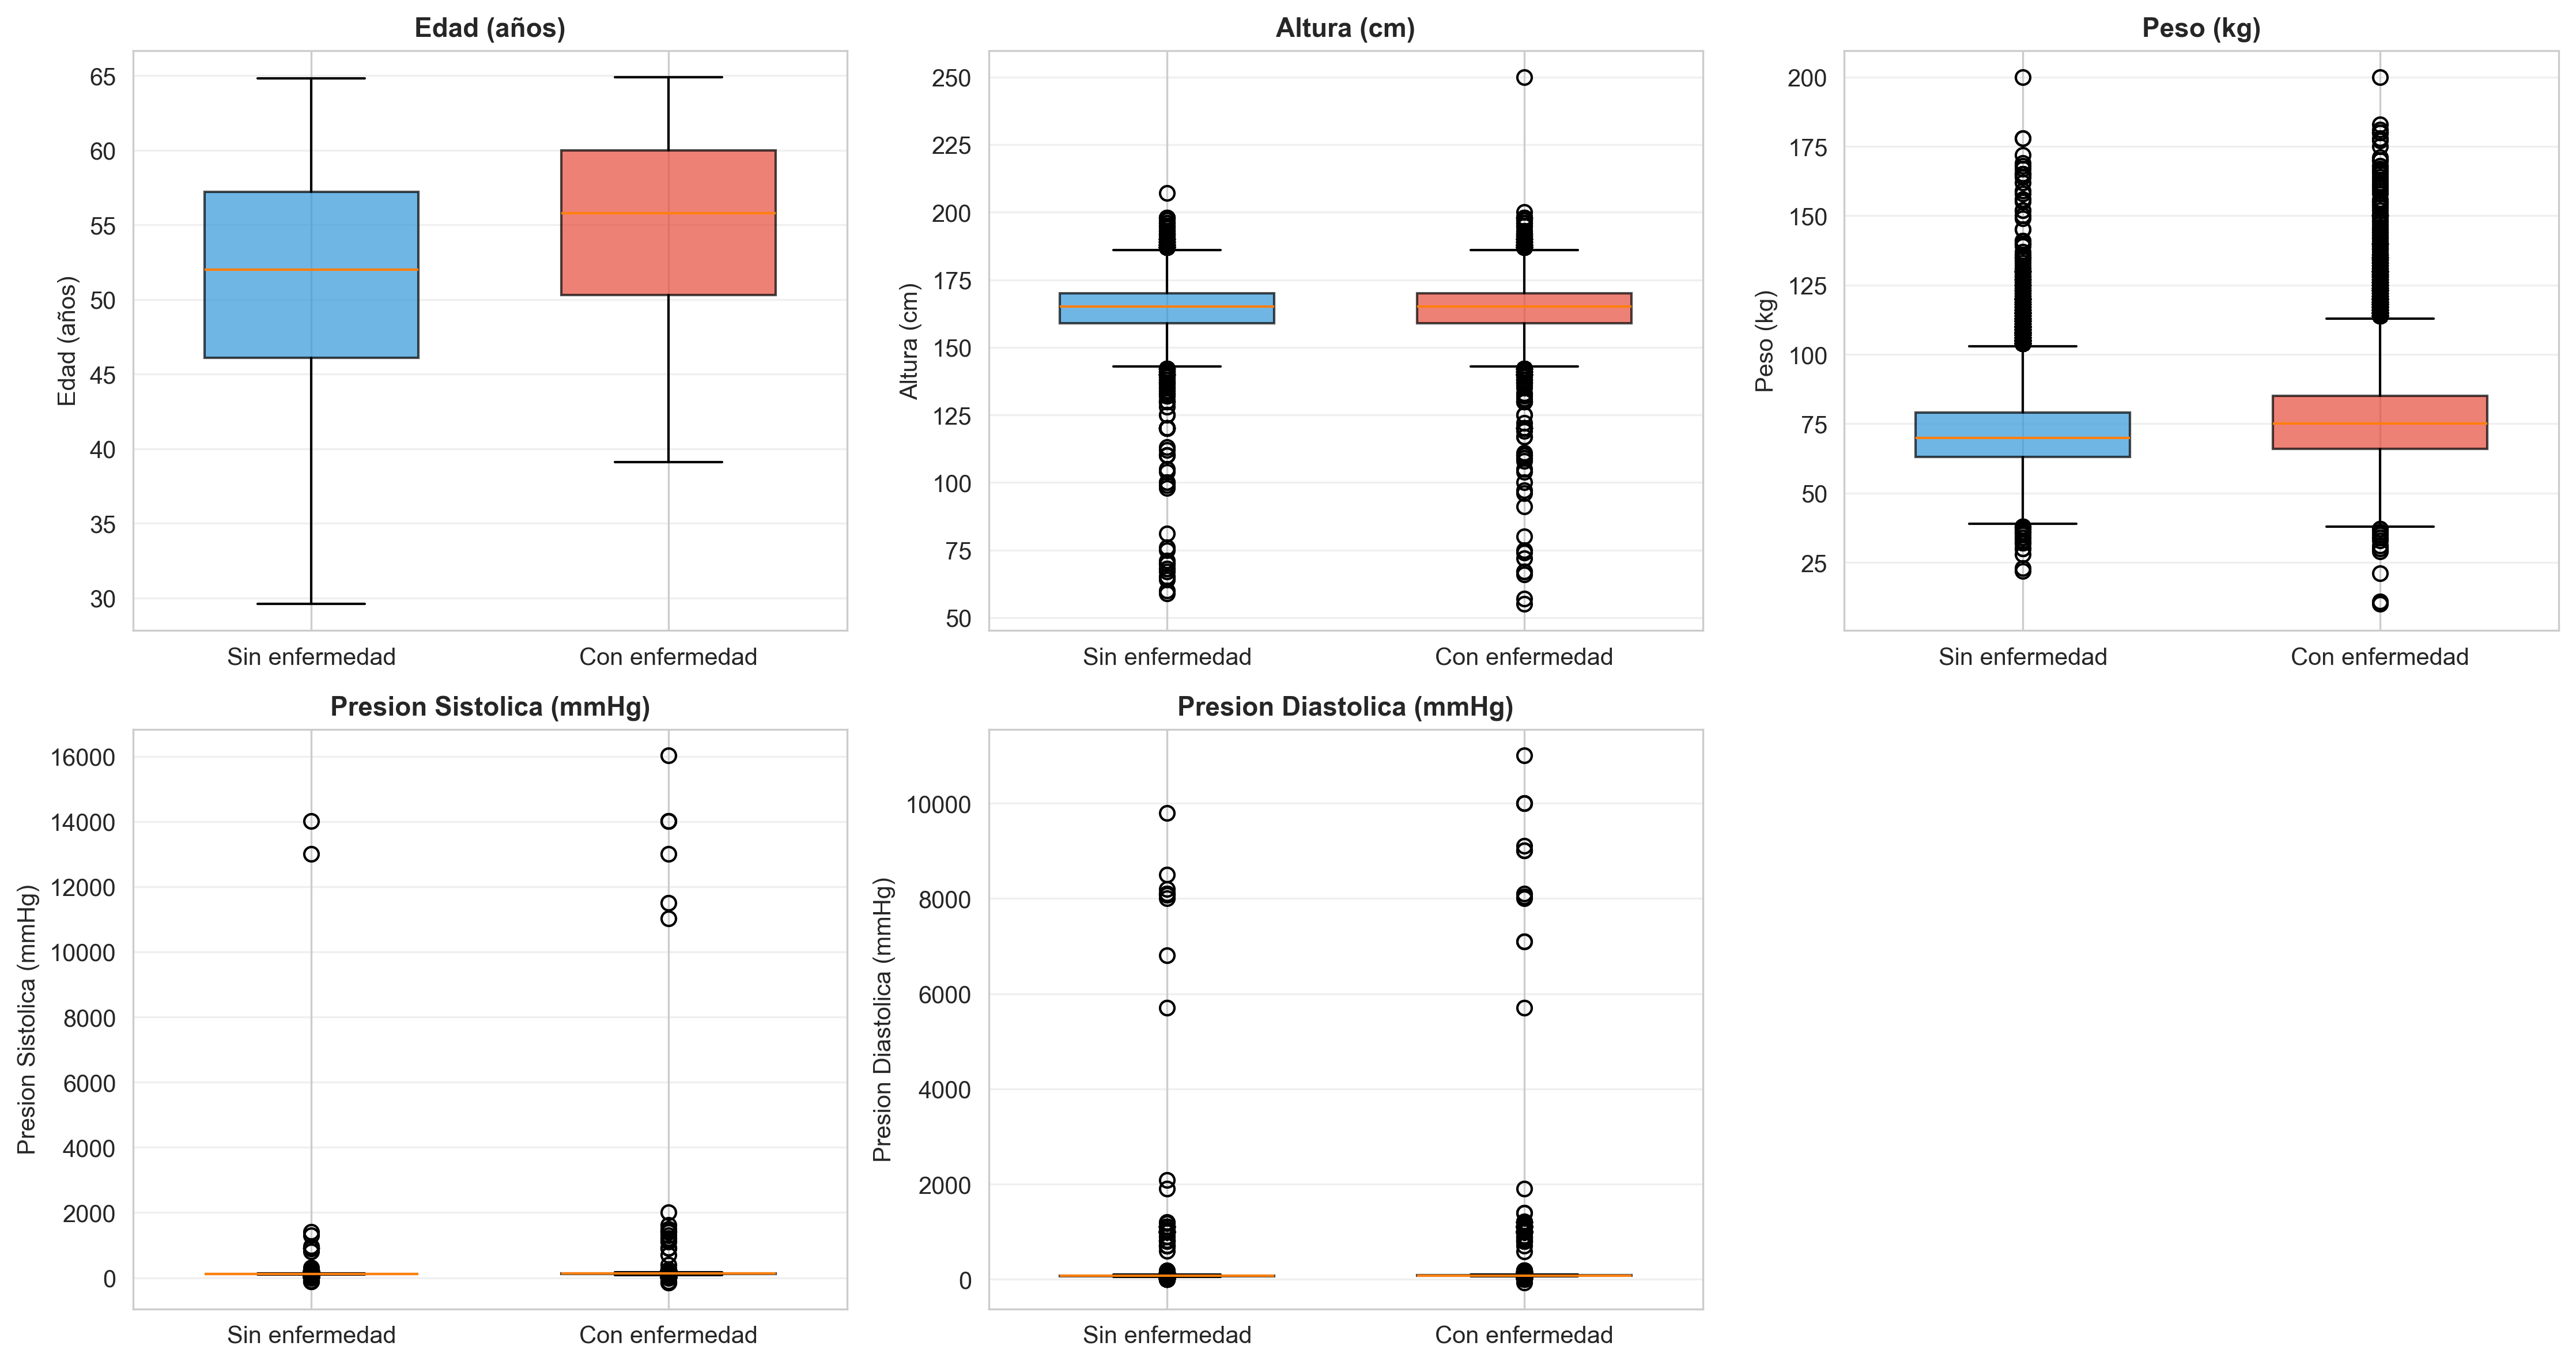

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (col, nombre) in enumerate(variables_num.items()):
    ax = axes[idx]
    
    # Boxplot comparativo
    datos = [df[df['cardio'] == 0][col], df[df['cardio'] == 1][col]]
    bp = ax.boxplot(datos, labels=['Sin enfermedad', 'Con enfermedad'],
                     patch_artist=True, widths=0.6)
    
    # Colores
    colors = ['#3498db', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.set_ylabel(nombre, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Comparación estadística
print("Comparación de Medias por Grupo:\n")
print(f"{'Variable':<25} {'Sin Enfermedad':<20} {'Con Enfermedad':<20} {'Diferencia':<15}")
print("="*80)

for col, nombre in variables_num.items():
    media_0 = df[df['cardio'] == 0][col].mean()
    media_1 = df[df['cardio'] == 1][col].mean()
    diff = media_1 - media_0
    print(f"{nombre:<25} {media_0:<20.2f} {media_1:<20.2f} {diff:+.2f}")

Comparación de Medias por Grupo:

Variable                  Sin Enfermedad       Con Enfermedad       Diferencia     
Edad (años)               51.70                54.91                +3.22
Altura (cm)               164.45               164.27               -0.18
Peso (kg)                 71.59                76.82                +5.23
Presion Sistolica (mmHg)  120.43               137.21               +16.78
Presion Diastolica (mmHg) 84.25                109.02               +24.77


**Interpretación:**

- Los pacientes con enfermedad cardiovascular presentan mayor edad promedio
- La presión arterial (sistólica y diastólica) es significativamente mayor en el grupo con enfermedad
- El peso también muestra una diferencia notable entre grupos
- Estas diferencias sugieren que estas variables tienen poder discriminatorio para la predicción

## 6. Análisis de Variables Categóricas

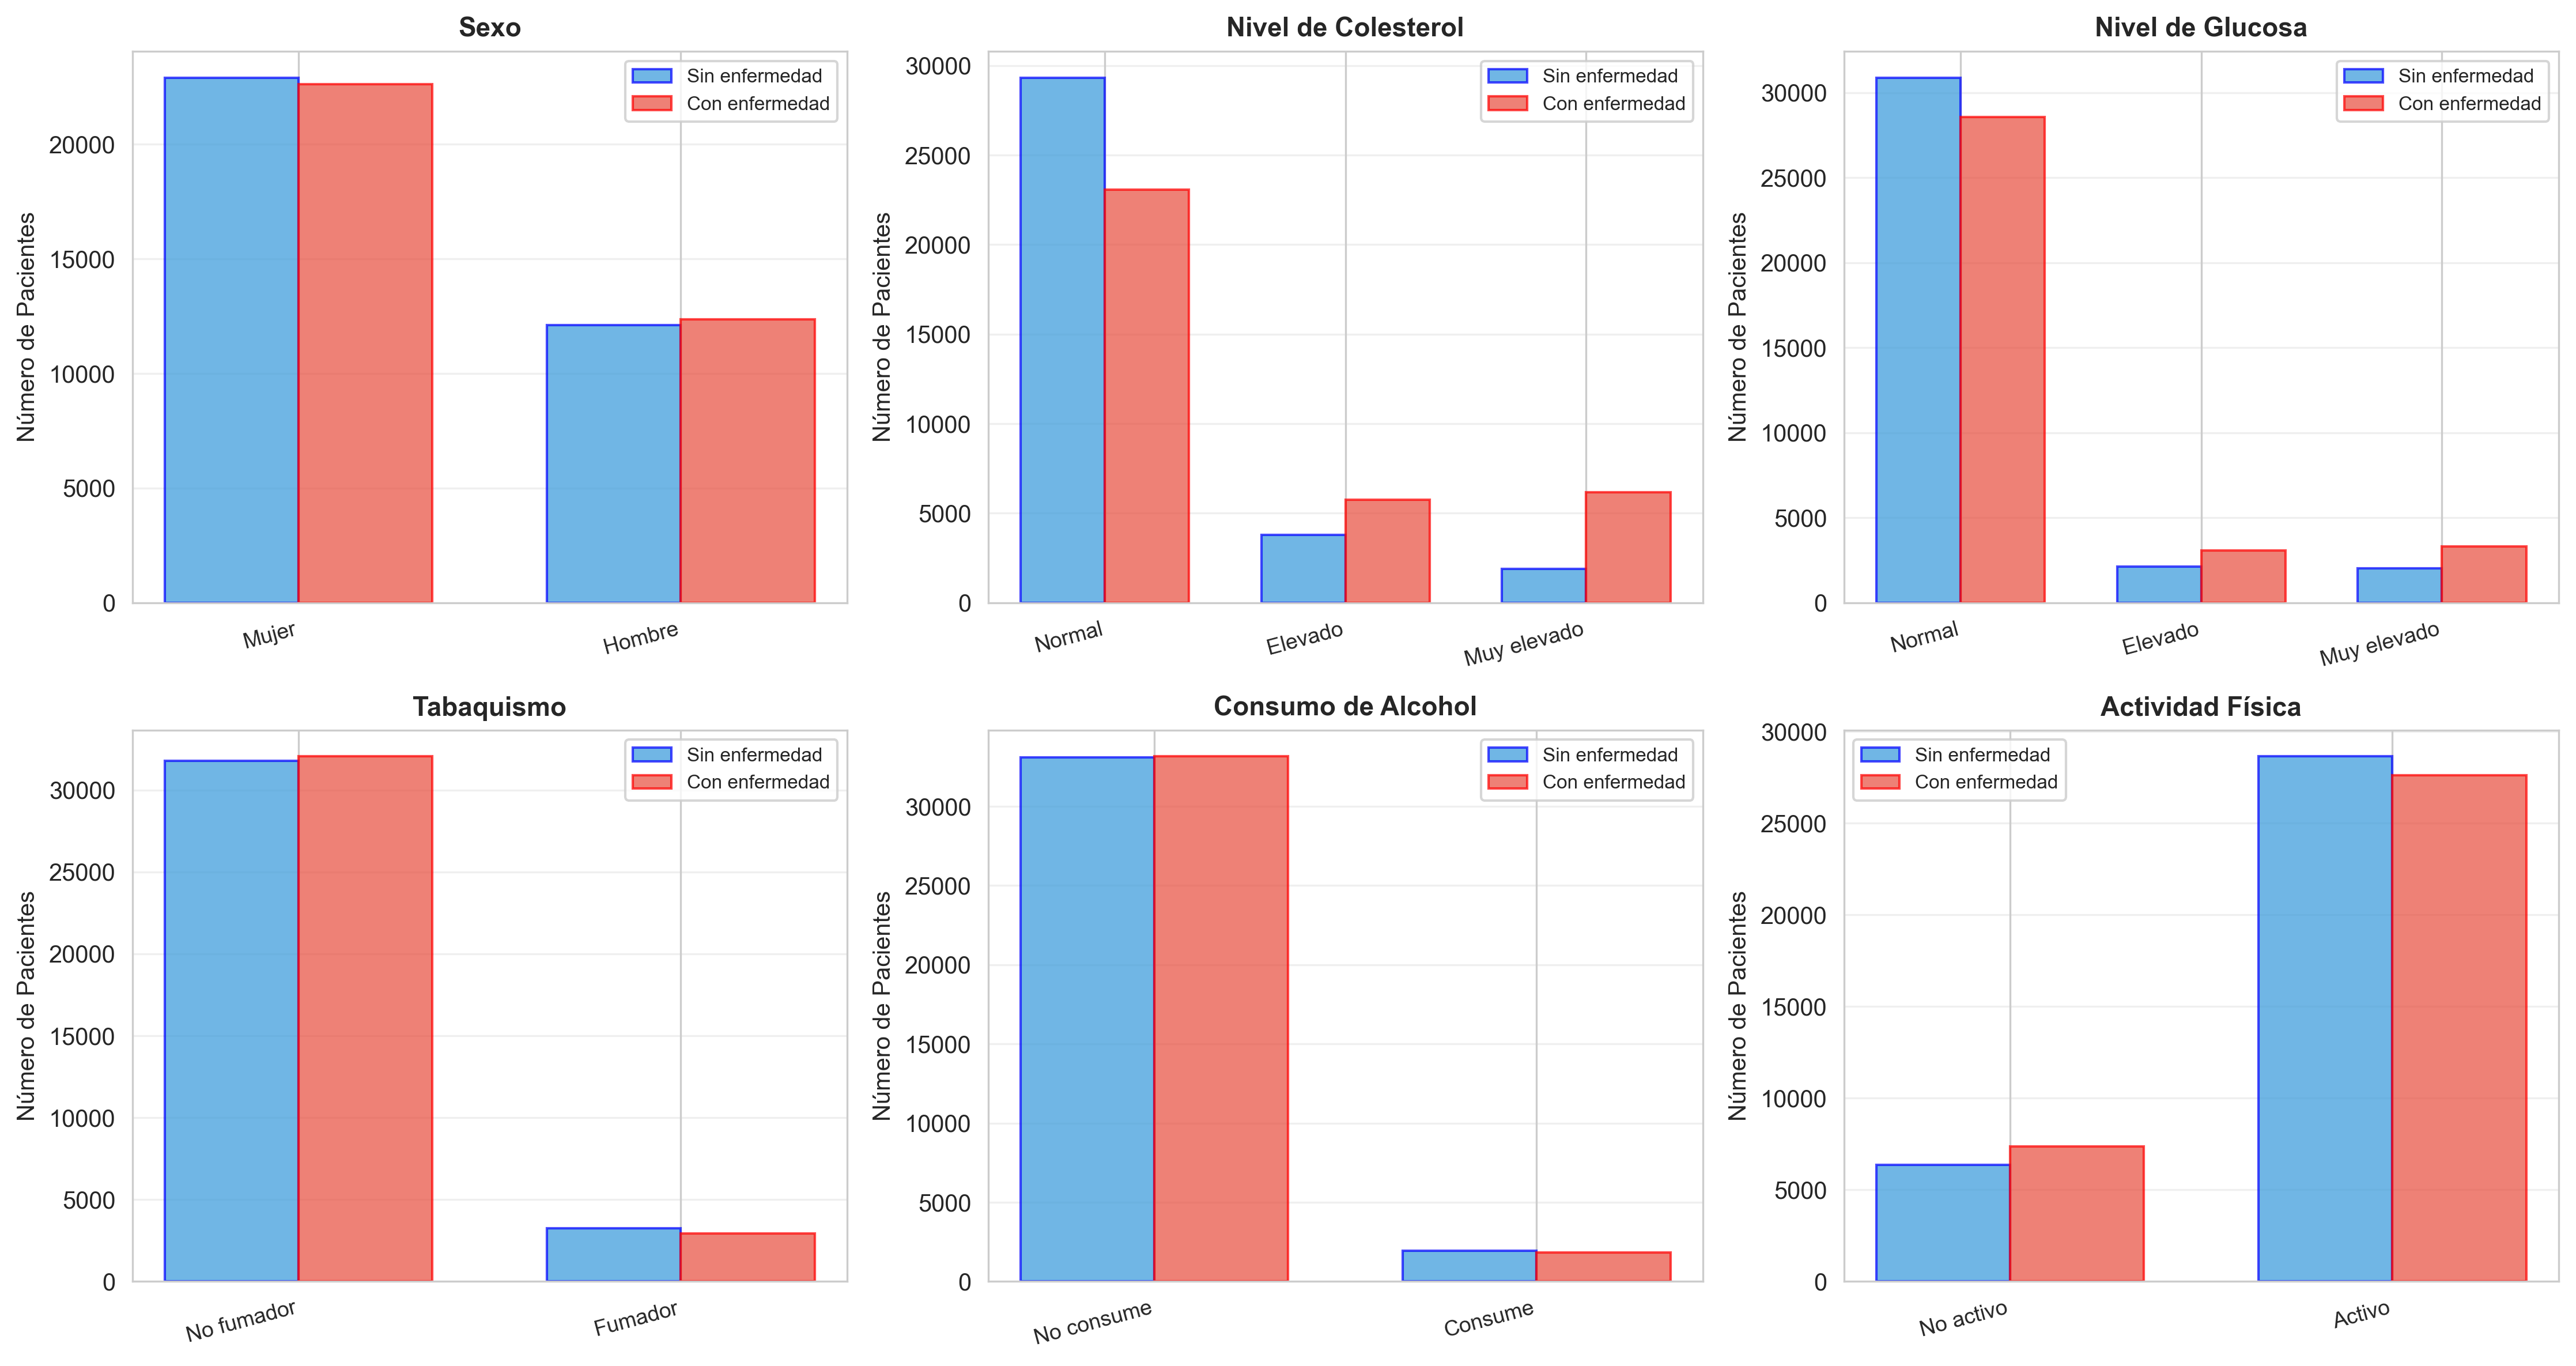

In [10]:
variables_cat = {
    'gender': {1: 'Mujer', 2: 'Hombre'},
    'cholesterol': {1: 'Normal', 2: 'Elevado', 3: 'Muy elevado'},
    'gluc': {1: 'Normal', 2: 'Elevado', 3: 'Muy elevado'},
    'smoke': {0: 'No fumador', 1: 'Fumador'},
    'alco': {0: 'No consume', 1: 'Consume'},
    'active': {0: 'No activo', 1: 'Activo'}
}

nombres_vars = {
    'gender': 'Sexo',
    'cholesterol': 'Nivel de Colesterol',
    'gluc': 'Nivel de Glucosa',
    'smoke': 'Tabaquismo',
    'alco': 'Consumo de Alcohol',
    'active': 'Actividad Física'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (var, etiquetas) in enumerate(variables_cat.items()):
    ax = axes[idx]
    
    # Crear tabla de contingencia
    tabla = pd.crosstab(df[var], df['cardio'])
    
    # Gráfico de barras agrupadas
    x_pos = np.arange(len(etiquetas))
    width = 0.35
    
    ax.bar(x_pos - width/2, tabla[0], width, label='Sin enfermedad', 
           color='#3498db', alpha=0.7, edgecolor='blue')
    ax.bar(x_pos + width/2, tabla[1], width, label='Con enfermedad', 
           color='#e74c3c', alpha=0.7, edgecolor='red')
    
    
    ax.set_title(nombres_vars[var], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Número de Pacientes', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(etiquetas.values(), rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Análisis de proporciones
print("Proporción de Enfermedad Cardiovascular por Categoría:\n")

for var, etiquetas in variables_cat.items():
    print(f"\n{nombres_vars[var]}:")
    tabla = pd.crosstab(df[var], df['cardio'], normalize='index') * 100
    
    for categoria, nombre_cat in etiquetas.items():
        if categoria in tabla.index:
            pct_enfermedad = tabla.loc[categoria, 1]
            print(f"  {nombre_cat}: {pct_enfermedad:.1f}% con enfermedad")

Proporción de Enfermedad Cardiovascular por Categoría:


Sexo:
  Mujer: 49.7% con enfermedad
  Hombre: 50.5% con enfermedad

Nivel de Colesterol:
  Normal: 44.0% con enfermedad
  Elevado: 60.2% con enfermedad
  Muy elevado: 76.5% con enfermedad

Nivel de Glucosa:
  Normal: 48.1% con enfermedad
  Elevado: 59.3% con enfermedad
  Muy elevado: 62.2% con enfermedad

Tabaquismo:
  No fumador: 50.2% con enfermedad
  Fumador: 47.5% con enfermedad

Consumo de Alcohol:
  No consume: 50.1% con enfermedad
  Consume: 48.4% con enfermedad

Actividad Física:
  No activo: 53.6% con enfermedad
  Activo: 49.1% con enfermedad


**Observaciones:**

- **Colesterol y Glucosa:** Muestran una relación clara con la enfermedad cardiovascular. Los niveles elevados y muy elevados presentan mayor proporción de enfermedad
- **Actividad Física:** Las personas activas muestran menor prevalencia de enfermedad cardiovascular
- **Tabaquismo y Alcohol:** Sorprendentemente, la relación no es tan pronunciada como se esperaría
- **Sexo:** Diferencias mínimas en la prevalencia entre hombres y mujeres

## 7. Análisis de Correlaciones

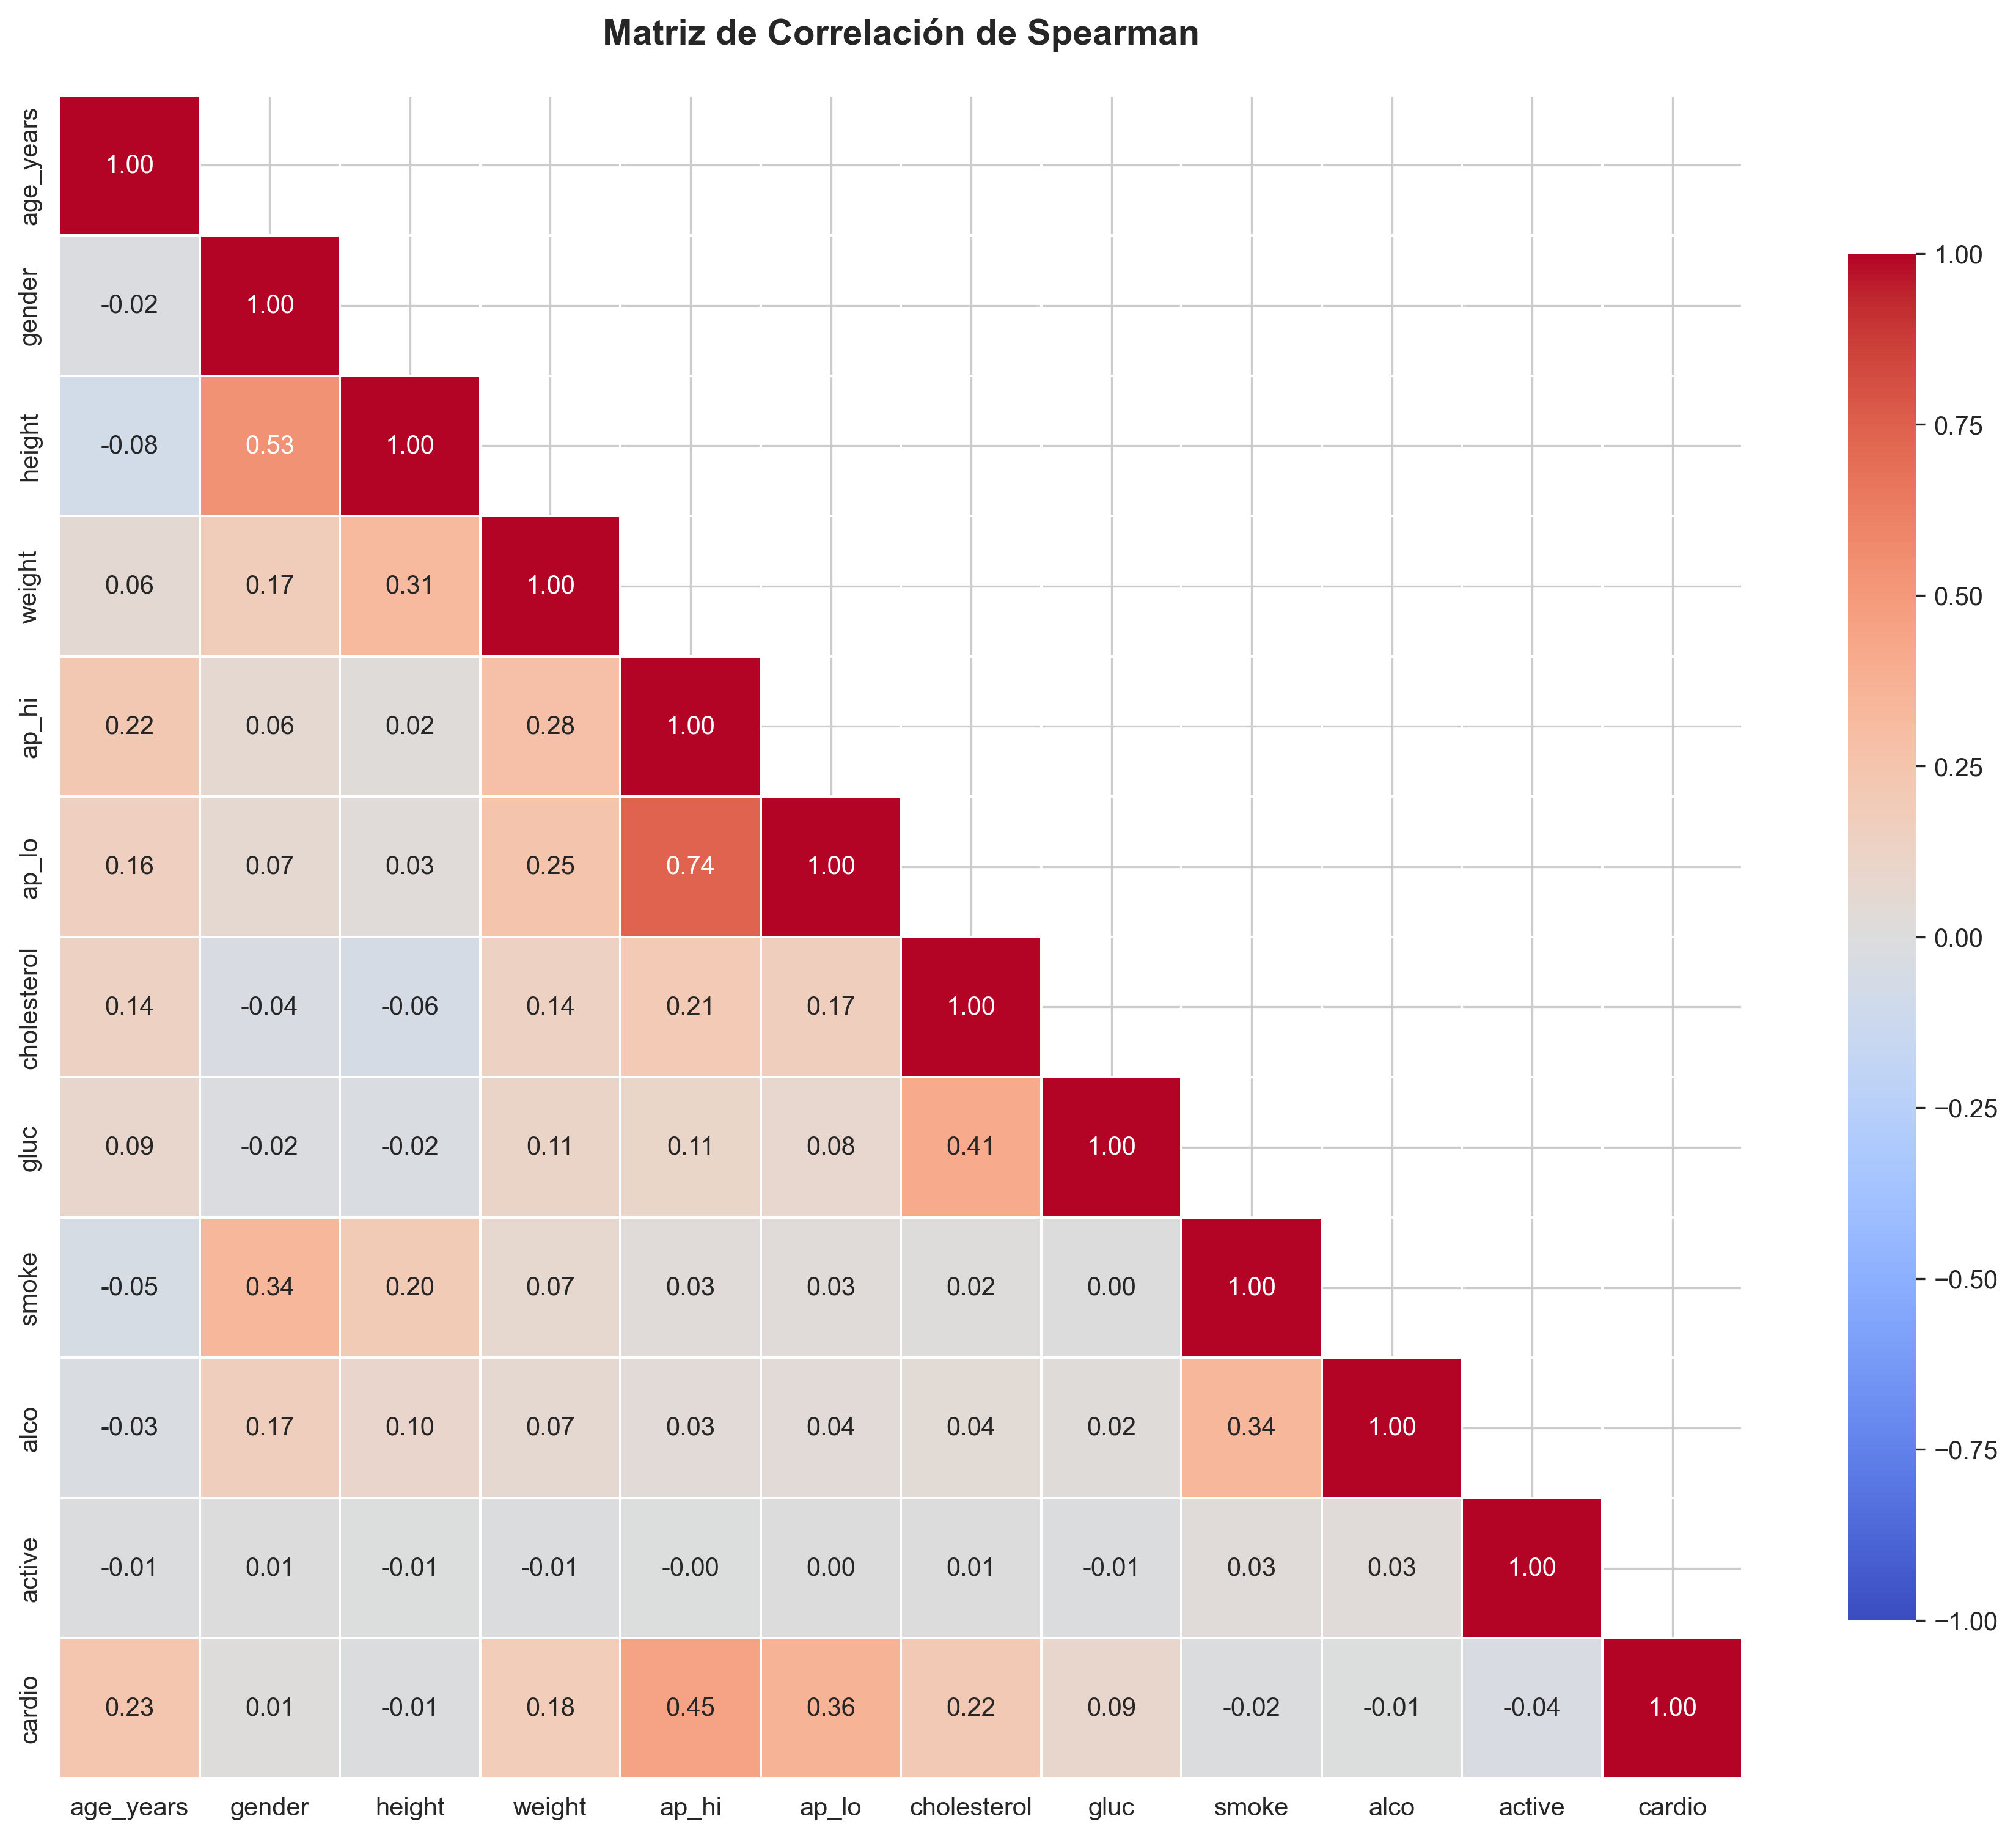

In [12]:
# Seleccionar variables para correlación
cols_corr = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
             'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

# Calcular matriz de correlación (Spearman para incluir ordinales)
corr_matrix = df[cols_corr].corr(method='spearman')

# Visualización
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title('Matriz de Correlación de Spearman', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [13]:
# Correlaciones más fuertes con la variable objetivo
corr_cardio = corr_matrix['cardio'].drop('cardio').sort_values(ascending=False)

print("Correlaciones con la Variable Objetivo (cardio):\n")
print(f"{'Variable':<20} {'Correlación':<15}")
print("="*35)
for var, corr in corr_cardio.items():
    print(f"{var:<20} {corr:>+.4f}")

Correlaciones con la Variable Objetivo (cardio):

Variable             Correlación    
ap_hi                +0.4519
ap_lo                +0.3626
age_years            +0.2344
cholesterol          +0.2151
weight               +0.1827
gluc                 +0.0915
gender               +0.0081
alco                 -0.0073
height               -0.0124
smoke                -0.0155
active               -0.0357


**Interpretación:**

Las variables con mayor correlación con la presencia de enfermedad cardiovascular son:
1. **Presión arterial** (sistólica y diastólica): correlación positiva moderada
2. **Colesterol**: correlación positiva moderada
3. **Edad**: correlación positiva moderada
4. **Peso**: correlación positiva leve

Es notable que:
- Las presiones arteriales están altamente correlacionadas entre sí (0.74)
- Colesterol y glucosa muestran correlación positiva (0.41)
- El tabaquismo y consumo de alcohol tienen correlaciones muy bajas con la variable objetivo

## 8. Índice de Masa Corporal (IMC)

In [14]:
# Calcular IMC
df['imc'] = df['weight'] / ((df['height'] / 100) ** 2)

# Categorizar IMC según OMS
def categorizar_imc(imc):
    if imc < 18.5:
        return 'Bajo peso'
    elif imc < 25:
        return 'Normal'
    elif imc < 30:
        return 'Sobrepeso'
    else:
        return 'Obesidad'

df['categoria_imc'] = df['imc'].apply(categorizar_imc)

# Análisis
print("Distribución de IMC:\n")
print(df['categoria_imc'].value_counts())

print("\n\nProporción de enfermedad cardiovascular por categoría de IMC:\n")
tabla_imc = pd.crosstab(df['categoria_imc'], df['cardio'], normalize='index') * 100
print(tabla_imc[1].sort_values(ascending=False))

Distribución de IMC:

categoria_imc
Normal       25790
Sobrepeso    25086
Obesidad     18474
Bajo peso      650
Name: count, dtype: int64


Proporción de enfermedad cardiovascular por categoría de IMC:

categoria_imc
Obesidad     63.067013
Sobrepeso    51.008531
Normal       40.131834
Bajo peso    28.000000
Name: 1, dtype: float64


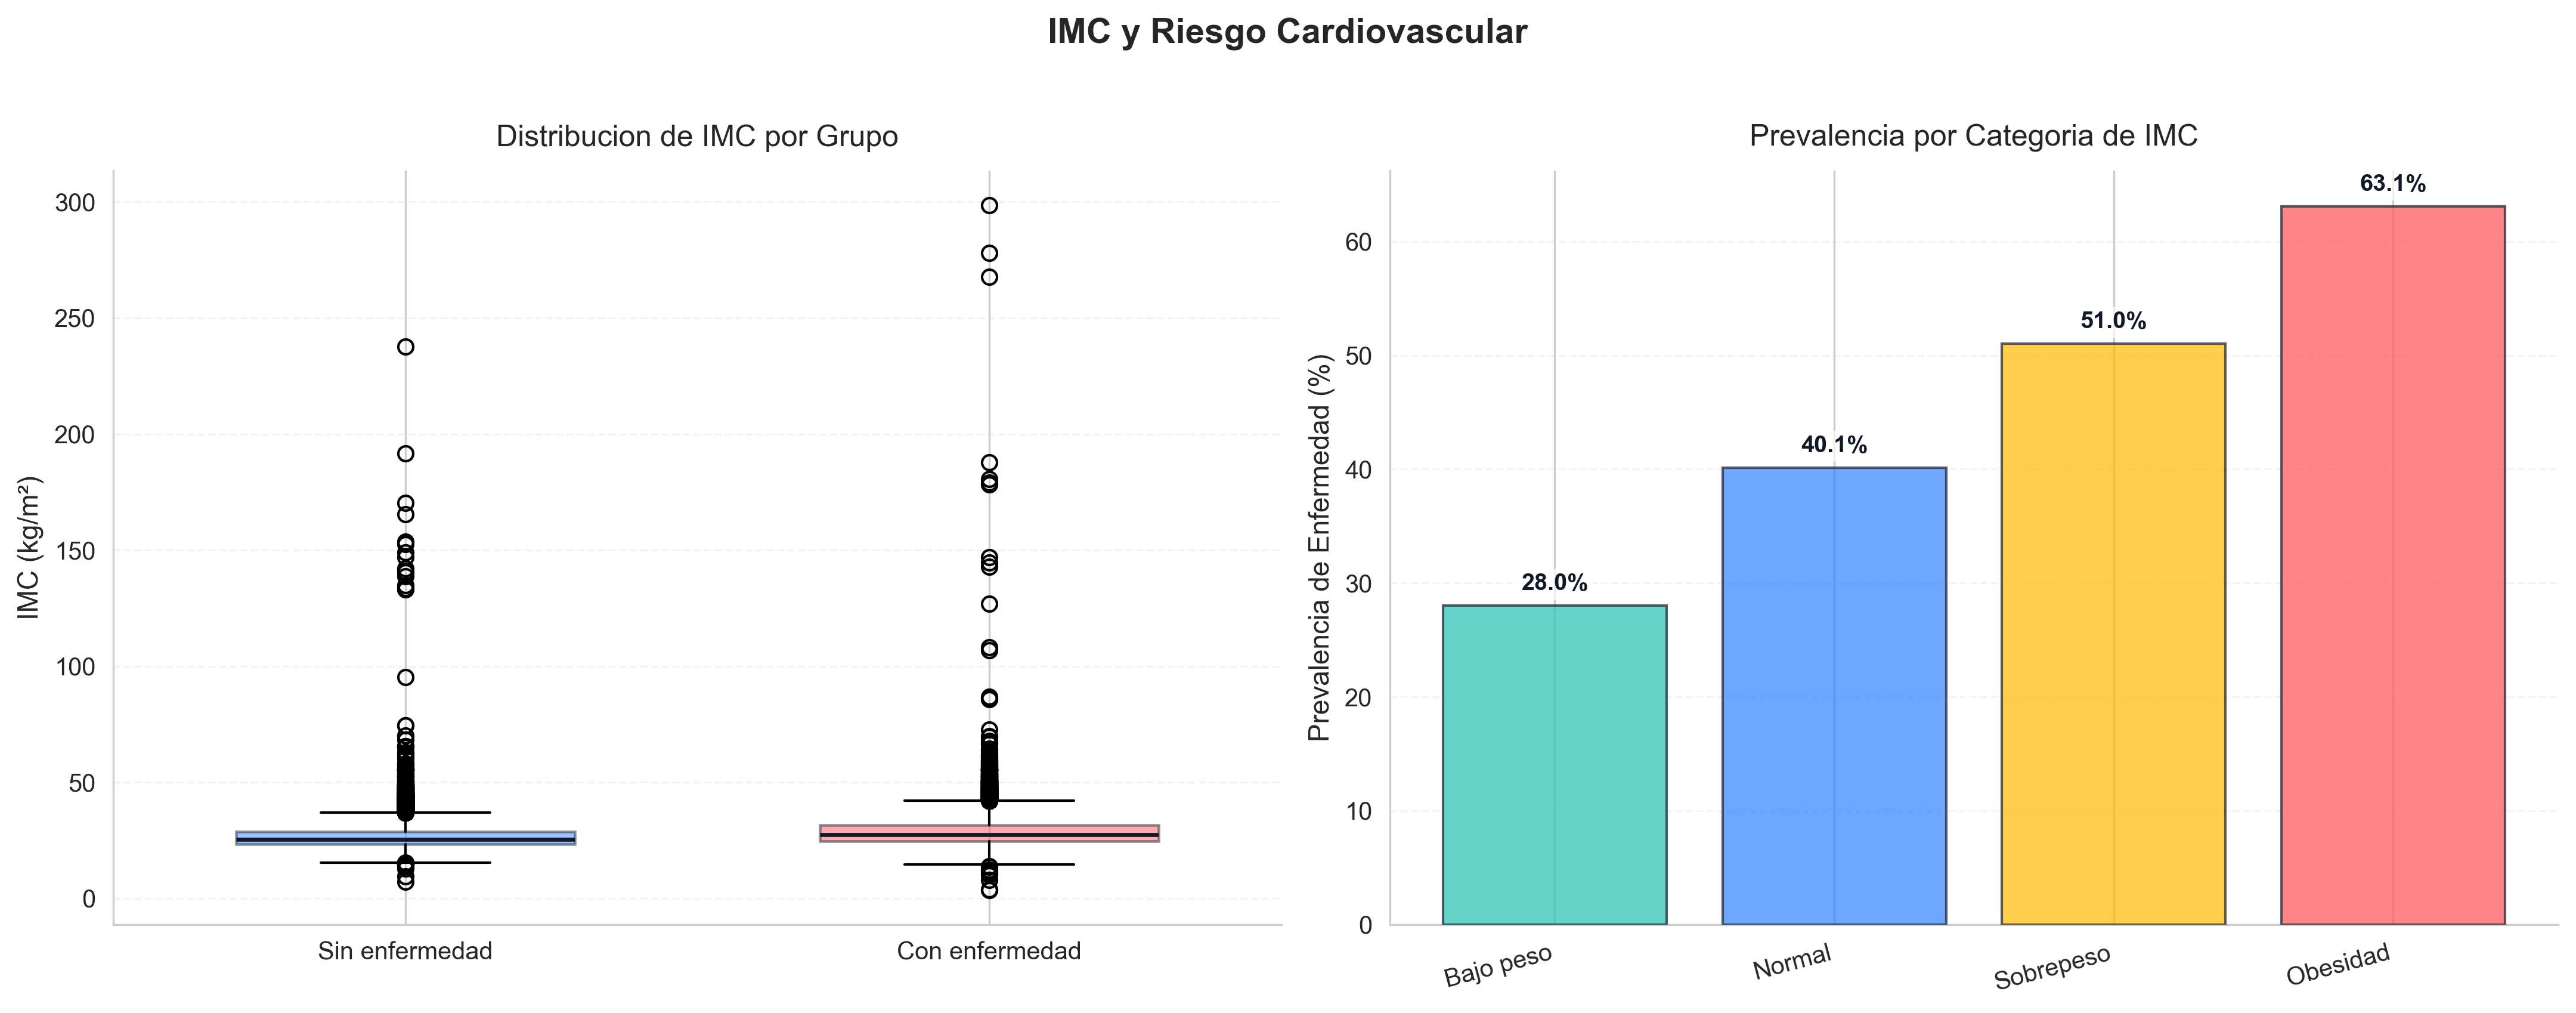

In [15]:
# Visualizacion IMC vs Enfermedad Cardiovascular
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.5))

# Distribucion de IMC por grupo
ax1 = axes[0]
datos_imc = [df[df['cardio'] == 0]['imc'], df[df['cardio'] == 1]['imc']]
bp = ax1.boxplot(
    datos_imc,
    labels=['Sin enfermedad', 'Con enfermedad'],
    patch_artist=True,
    widths=0.58,
    medianprops=dict(color='#111827', linewidth=1.6),
)

for patch, color in zip(bp['boxes'], ['#3A86FF', '#FF5A5F']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
    patch.set_edgecolor('#1F2937')
    patch.set_linewidth(1.1)

ax1.set_ylabel('IMC (kg/m²)', fontsize=11)
ax1.set_title('Distribucion de IMC por Grupo', fontsize=12, pad=10)
ax1.grid(axis='y', alpha=0.22, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Prevalencia por categoria de IMC
ax2 = axes[1]
orden = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
prevalencia = []
for cat in orden:
    if cat in tabla_imc.index:
        prevalencia.append(tabla_imc.loc[cat, 1])
    else:
        prevalencia.append(0)

bars = ax2.bar(
    orden,
    prevalencia,
    color=['#2EC4B6', '#3A86FF', '#FFBE0B', '#FF5A5F'],
    alpha=0.74,
    edgecolor='#1F2937',
    linewidth=1.0,
    zorder=3,
 )

ax2.set_ylabel('Prevalencia de Enfermedad (%)', fontsize=11)
ax2.set_title('Prevalencia por Categoria de IMC', fontsize=12, pad=10)
ax2.set_xticks(range(len(orden)))
ax2.set_xticklabels(orden, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.22, linestyle='--', zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Agregar valores
for bar, val in zip(bars, prevalencia):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(prevalencia) * 0.015 if max(prevalencia) > 0 else 0.1,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9.5,
        fontweight='bold',
        color='#111827',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.68, boxstyle='round,pad=0.2')
    )

fig.suptitle('IMC y Riesgo Cardiovascular', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** Se observa una tendencia clara: a mayor IMC, mayor prevalencia de enfermedad cardiovascular. Los pacientes con obesidad presentan la mayor proporción de enfermedad, seguidos por aquellos con sobrepeso.

## 9. Conclusiones del Análisis Exploratorio

### 9.1 Hallazgos Principales

1. **Dataset bien balanceado:** La distribución 50-50 de la variable objetivo facilita el modelado predictivo sin necesidad de técnicas de balanceo.

2. **Variables más relevantes identificadas:**
   - Presión arterial (sistólica y diastólica): mayor correlación con enfermedad cardiovascular
   - Colesterol: niveles elevados asociados fuertemente con enfermedad
   - Edad: factor de riesgo importante
   - IMC/Peso: obesidad correlacionada con mayor riesgo

3. **Calidad de datos:**
   - No se detectaron valores nulos
   - Se identificaron valores atípicos y fisiológicamente imposibles que requieren limpieza
   - Presencia de registros duplicados que deben ser evaluados

4. **Hallazgos inesperados:**
   - La correlación de tabaquismo y consumo de alcohol con enfermedad cardiovascular es menor de lo esperado
   - Esto podría deberse a subregistro, sesgo en la recolección o factores confusores

### 9.2 Recomendaciones para Preprocesamiento

1. **Limpieza de datos:**
   - Filtrar registros con presión sistólica ≤ diastólica
   - Eliminar valores de presión arterial fuera de rangos fisiológicos (< 80 o > 200 sistólica, < 60 o > 140 diastólica)
   - Revisar y tratar alturas y pesos extremos
   - Evaluar registros duplicados

2. **Ingeniería de características:**
   - Incorporar IMC como variable derivada
   - Considerar crear rangos de edad para capturar efectos no lineales
   - Evaluar interacciones entre presión arterial y colesterol

3. **Normalización:**
   - Las variables numéricas requieren normalización/estandarización para modelos sensibles a escala